
# Triadic Cell Notebook v31
## Real recursive fold controller

This notebook continues directly from v30.

v30 restored the retrieve branch and produced a sane field object:

$$
Q \to (\text{retrieve mask},\ \text{missing mask},\ \text{fold field},\ \text{declared value})
$$

But it still emitted that field only once.

v31 adds the missing mechanic:

## recursion

The controller now consumes its own fold field repeatedly:

$$
Q_t \to (R_t,\ M_t,\ F_t,\ V_t)
$$

then updates the query:

$$
Q_{t+1} = \operatorname{clip}\!\left(Q_t + \lambda F_t\right)
$$

with damping and contradiction penalty, and repeats until one of these happens:

- missing mass stops decreasing
- candidate identity stabilizes
- retrieve mode stabilizes
- maximum recursion depth is reached

This is the first notebook in the line that actually **uses** the fold field instead of only reporting it.



## Practical meaning

This is still runtime control, not base-model training.

The point is simple:

- first pass diagnoses the field
- recursion uses the diagnosis to improve the query state
- later passes refine class identity and closure

This should help most on **partial** inputs, because those already have the right field geometry but were not being iteratively completed.


In [1]:

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.



## Canonical triadic chain


In [2]:

n_classes = 4
dim = 6

base_molds = np.array([
    [
        [0.95, 0.15, 0.10, 0.20, 0.30, 0.10],
        [0.70, 0.25, 0.45, 0.30, 0.45, 0.20],
        [0.55, 0.20, 0.60, 0.25, 0.70, 0.35],
    ],
    [
        [0.10, 0.95, 0.15, 0.25, 0.10, 0.30],
        [0.25, 0.72, 0.25, 0.50, 0.25, 0.45],
        [0.20, 0.58, 0.30, 0.70, 0.30, 0.72],
    ],
    [
        [0.20, 0.10, 0.95, 0.15, 0.25, 0.12],
        [0.45, 0.25, 0.75, 0.30, 0.42, 0.22],
        [0.62, 0.22, 0.55, 0.25, 0.72, 0.30],
    ],
    [
        [0.15, 0.22, 0.18, 0.95, 0.12, 0.35],
        [0.28, 0.42, 0.25, 0.75, 0.22, 0.58],
        [0.35, 0.72, 0.30, 0.60, 0.25, 0.78],
    ],
], dtype=float)

def normalize01(x):
    return np.clip(x, 0.0, 1.0)

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def chain_mix(prev_shape: np.ndarray, local_mold: np.ndarray, alpha: float = 0.58):
    return normalize01(alpha * prev_shape + (1.0 - alpha) * local_mold)

def build_chain_for_class(cls: int):
    s0 = normalize01(base_molds[cls, 0].copy())
    s1 = chain_mix(s0, base_molds[cls, 1], alpha=0.58)
    s2 = chain_mix(s1, base_molds[cls, 2], alpha=0.58)
    return [s0, s1, s2]

chains = {cls: build_chain_for_class(cls) for cls in range(n_classes)}
pd.DataFrame(chains[0], index=["shape", "bridge_value", "declared_value"])


,0,1,2,3,4,5
shape,0.9500,0.15000,0.10000,0.20000,0.30000,0.10000
bridge_value,0.8450,0.19200,0.24700,0.24200,0.36300,0.14200
declared_value,0.7211,0.19536,0.39526,0.24536,0.50454,0.22936



## Directional basis


In [3]:

raw_basis = np.array([
    [1.0, 0.0, 0.6, 0.2, 0.0, 0.3],
    [0.2, 1.0, 0.0, 0.6, 0.2, 0.0],
    [0.0, 0.2, 1.0, 0.0, 0.6, 0.2],
    [0.6, 0.0, 0.2, 1.0, 0.0, 0.6],
    [0.0, 0.6, 0.2, 0.0, 1.0, 0.2],
], dtype=float)

basis = []
for v in raw_basis:
    u = v.copy()
    for b in basis:
        u = u - np.dot(u, b) * b
    n = np.linalg.norm(u)
    if n > 1e-8:
        basis.append(u / n)

U = np.stack(basis, axis=0)
U.shape


(5, 6)


## Query corruption


In [4]:

QUERY_MODES = ["existing", "partial", "noisy", "ambiguous", "inverse_hint"]
QUERY_WEIGHTS = np.array([0.28, 0.28, 0.18, 0.16, 0.10], dtype=float)
QUERY_WEIGHTS = QUERY_WEIGHTS / QUERY_WEIGHTS.sum()

def make_query(cls: int, mode: str):
    target = chains[cls][0].copy()
    q = target.copy()

    if mode == "existing":
        q += rng.normal(0.0, 0.02, size=q.shape[0])

    elif mode == "partial":
        mask = rng.random(q.shape[0]) < 0.40
        q[mask] = 0.0
        q += rng.normal(0.0, 0.02, size=q.shape[0])

    elif mode == "noisy":
        q += rng.normal(0.0, 0.08, size=q.shape[0])

    elif mode == "ambiguous":
        alt = int((cls + rng.integers(1, n_classes)) % n_classes)
        q = 0.58 * target + 0.42 * chains[alt][0] + rng.normal(0.0, 0.03, size=q.shape[0])

    elif mode == "inverse_hint":
        inv = 1.0 - target
        q = 0.65 * target + 0.35 * inv + rng.normal(0.0, 0.03, size=q.shape[0])
        mask = rng.random(q.shape[0]) < 0.20
        q[mask] = 0.0

    return normalize01(q)



## Directional decomposition


In [5]:

def directional_coeffs(x: np.ndarray):
    return U @ x

def reconstruct_from_coeffs(c: np.ndarray):
    return np.clip(c @ U, 0.0, 1.0)

def pythagorean_split(query: np.ndarray, target: np.ndarray):
    aq = directional_coeffs(query)
    at = directional_coeffs(target)

    aligned = np.minimum(aq, at)
    missing = np.maximum(at - aq, 0.0)
    excess = np.maximum(aq - at, 0.0)

    R = reconstruct_from_coeffs(aligned)
    M = reconstruct_from_coeffs(missing)
    E = reconstruct_from_coeffs(excess)

    aligned_energy = float(np.sum(aligned ** 2))
    missing_energy = float(np.sum(missing ** 2))
    excess_energy = float(np.sum(excess ** 2))
    total_energy = float(np.sum(at ** 2) + 1e-8)

    active_dirs = int(np.sum(np.abs(aq) > 0.10))
    boundary_complexity = int(np.sum(np.abs(at) > 0.12))
    boundary_eff = max(1.0, boundary_complexity / 2.0)
    nyquist_score = float(active_dirs / boundary_eff)

    return {
        "aq": aq,
        "at": at,
        "R": R,
        "M": M,
        "E": E,
        "aligned_ratio": float(aligned_energy / total_energy),
        "missing_ratio": float(missing_energy / total_energy),
        "excess_ratio": float(excess_energy / total_energy),
        "active_dirs": active_dirs,
        "boundary_complexity": boundary_complexity,
        "nyquist_score": nyquist_score,
    }



## Candidate evaluation


In [6]:

def triadic_evaluate(query: np.ndarray, cls: int):
    s0, s1, s2 = chains[cls]

    retrieve_fit = cosine_similarity(query, s0)
    split = pythagorean_split(query, s0)

    folded0 = normalize01(query + split["M"] - 0.25 * split["E"])
    projected1 = chain_mix(folded0, base_molds[cls, 1], alpha=0.58)
    projected2 = chain_mix(projected1, base_molds[cls, 2], alpha=0.58)

    bridge_energy = (
        0.35 * split["missing_ratio"]
        + 0.20 * split["excess_ratio"]
        + 0.25 * (1.0 - retrieve_fit)
        + 0.20 * max(0.0, 1.0 - split["nyquist_score"])
    )

    closure_score = (
        0.60 * retrieve_fit
        + 0.35 * split["aligned_ratio"]
        - 0.90 * split["missing_ratio"]
        - 0.45 * split["excess_ratio"]
        - 0.50 * bridge_energy
    )

    declaration_score = closure_score + 0.18 * min(split["nyquist_score"], 2.0)

    return {
        "class": cls,
        "retrieve_fit": float(retrieve_fit),
        "bridge_energy": float(bridge_energy),
        "closure_score": float(closure_score),
        "declaration_score": float(declaration_score),
        "R": split["R"],
        "M": split["M"],
        "E": split["E"],
        "aligned_ratio": split["aligned_ratio"],
        "missing_ratio": split["missing_ratio"],
        "excess_ratio": split["excess_ratio"],
        "nyquist_score": split["nyquist_score"],
        "declared_value": projected2,
    }

def triadic_query(query: np.ndarray):
    results = [triadic_evaluate(query, cls) for cls in range(n_classes)]
    results = sorted(results, key=lambda r: r["declaration_score"], reverse=True)
    best = results[0]
    second = results[1]
    margin = float(best["declaration_score"] - second["declaration_score"])
    return best, results, margin



## Calibrate retrieve/grow split on first pass

We keep the operating target:
- 35% retrieve
- 65% grow


In [7]:

rows = []
n_per_class = 700

for cls in range(n_classes):
    for _ in range(n_per_class):
        mode = rng.choice(QUERY_MODES, p=QUERY_WEIGHTS)
        q = make_query(cls, mode)
        best, all_results, margin = triadic_query(q)

        rows.append({
            "query": q,
            "true_class": cls,
            "query_mode": mode,
            "predicted_class": best["class"],
            "correct": int(best["class"] == cls),
            "margin": margin,
            "retrieve_fit": best["retrieve_fit"],
            "bridge_energy": best["bridge_energy"],
            "closure_score": best["closure_score"],
            "declaration_score": best["declaration_score"],
            "missing_ratio": best["missing_ratio"],
            "nyquist_score": best["nyquist_score"],
        })

world_df = pd.DataFrame(rows)

perm = rng.permutation(len(world_df))
split = int(0.5 * len(world_df))
cal_df = world_df.iloc[perm[:split]].reset_index(drop=True)
eval_df = world_df.iloc[perm[split:]].reset_index(drop=True)

target_retrieve_fraction = 0.35
retrieve_threshold = float(cal_df["declaration_score"].quantile(1.0 - target_retrieve_fraction))
retrieve_threshold


1.2780704554873628


## Field emission for one pass


In [8]:

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def produce_fields(query: np.ndarray, threshold: float):
    best, all_results, margin = triadic_query(query)

    mode = "retrieve" if best["declaration_score"] >= threshold else "grow"

    closure_permission = sigmoid(8.0 * (best["declaration_score"] - threshold))
    nyquist_permission = sigmoid(5.0 * (best["nyquist_score"] - 1.0))
    margin_permission = sigmoid(10.0 * (margin - 0.05))
    permission = float(closure_permission * nyquist_permission * margin_permission)

    retrieve_mask = normalize01(best["R"] * permission)
    missing_mask = normalize01(best["M"])
    contradiction_mask = normalize01(best["E"])

    # signed correction lives in [-1, 1]
    signed_correction = best["M"] - 0.6 * best["E"]
    fold_field = normalize01(0.5 + 0.5 * signed_correction)

    total = retrieve_mask + missing_mask + 1e-8
    retrieve_mask = retrieve_mask / total
    missing_mask = missing_mask / total

    return {
        "predicted_class": best["class"],
        "mode": mode,
        "margin": margin,
        "retrieve_fit": best["retrieve_fit"],
        "bridge_energy": best["bridge_energy"],
        "closure_score": best["closure_score"],
        "declaration_score": best["declaration_score"],
        "nyquist_score": best["nyquist_score"],
        "permission": permission,
        "retrieve_mask": retrieve_mask,
        "missing_mask": missing_mask,
        "contradiction_mask": contradiction_mask,
        "fold_field": fold_field,
        "signed_correction": signed_correction,
        "declared_value": best["declared_value"],
    }



## Recursive fold loop

This is the new mechanic.

At each step:
- emit the field
- use the **signed correction**
- damp the update
- stop if missing no longer improves or if retrieve stabilizes


In [9]:

def recursive_fold(
    query: np.ndarray,
    threshold: float,
    max_steps: int = 8,
    step_size: float = 0.45,
    damping: float = 0.85,
    stall_eps: float = 1e-4,
):
    q = query.copy()
    history = []

    prev_missing = None
    stable_count = 0
    prev_class = None
    prev_mode = None

    for step in range(max_steps):
        f = produce_fields(q, threshold)
        missing_mass = float(f["missing_mask"].mean())
        retrieve_mass = float(f["retrieve_mask"].mean())
        fold_mass = float(f["fold_field"].mean())

        history.append({
            "step": step,
            "predicted_class": f["predicted_class"],
            "mode": f["mode"],
            "margin": f["margin"],
            "retrieve_fit": f["retrieve_fit"],
            "bridge_energy": f["bridge_energy"],
            "closure_score": f["closure_score"],
            "declaration_score": f["declaration_score"],
            "nyquist_score": f["nyquist_score"],
            "permission": f["permission"],
            "retrieve_mass": retrieve_mass,
            "missing_mass": missing_mass,
            "fold_mass": fold_mass,
            "query_norm": float(np.linalg.norm(q)),
        })

        # stopping logic
        if prev_missing is not None and abs(prev_missing - missing_mass) < stall_eps:
            stable_count += 1
        else:
            stable_count = 0

        if (
            prev_class == f["predicted_class"]
            and prev_mode == f["mode"]
            and stable_count >= 1
            and f["mode"] == "retrieve"
        ):
            break

        if stable_count >= 2:
            break

        # consume the fold field
        update = step_size * f["signed_correction"]
        q = normalize01(damping * q + (1.0 - damping) * normalize01(q + update))

        prev_missing = missing_mass
        prev_class = f["predicted_class"]
        prev_mode = f["mode"]

    final_fields = produce_fields(q, threshold)
    return q, pd.DataFrame(history), final_fields



## Single recursive example


In [10]:

example_cls = 1
example_mode = "partial"
q0 = make_query(example_cls, example_mode)

q_final, trace_df, final_fields = recursive_fold(
    q0,
    retrieve_threshold,
    max_steps=8,
    step_size=0.45,
    damping=0.85,
)

single_example = pd.DataFrame([{
    "true_class": example_cls,
    "query_mode": example_mode,
    "initial_predicted_class": int(trace_df.iloc[0]["predicted_class"]),
    "final_predicted_class": final_fields["predicted_class"],
    "initial_mode": trace_df.iloc[0]["mode"],
    "final_mode": final_fields["mode"],
    "initial_missing_mass": float(trace_df.iloc[0]["missing_mass"]),
    "final_missing_mass": float(final_fields["missing_mask"].mean()),
    "steps_used": int(len(trace_df)),
}])
single_example


,true_class,query_mode,initial_predicted_class,final_predicted_class,initial_mode,final_mode,initial_missing_mass,final_missing_mass,steps_used
0,1,partial,3,3,grow,grow,0.999908,0.95307,8


In [11]:

trace_df


,step,predicted_class,mode,margin,retrieve_fit,bridge_energy,closure_score,declaration_score,nyquist_score,permission,retrieve_mass,missing_mass,fold_mass,query_norm
0,0,3,grow,0.490125,0.808639,0.225846,-0.042855,0.197145,1.333333,0.000146,0.000092,0.999908,0.612577,0.381242
1,1,3,grow,0.609066,0.849859,0.193357,0.064632,0.424632,2.000000,0.001071,0.000760,0.999240,0.605082,0.419437
2,2,3,grow,0.686156,0.878448,0.166838,0.155034,0.515034,2.000000,0.002210,0.001760,0.998240,0.598089,0.456993
3,3,3,grow,0.735499,0.898884,0.144810,0.232482,0.592482,2.000000,0.004101,0.003674,0.996326,0.591566,0.493332
4,4,3,grow,0.746363,0.913903,0.126274,0.299742,0.659742,2.000000,0.007003,0.006991,0.993009,0.585481,0.528145
5,5,3,grow,0.756703,0.925220,0.110528,0.358746,0.718746,2.000000,0.011181,0.012324,0.987676,0.579803,0.561278
6,6,3,grow,0.768060,0.933938,0.097060,0.410901,0.770901,2.000000,0.016874,0.020345,0.979654,0.574506,0.592671
7,7,3,grow,0.779547,0.940785,0.085478,0.457271,0.817271,2.000000,0.024269,0.031705,0.968294,0.569564,0.622324



## Compare first pass vs recursive pass across the evaluation world


In [12]:

rows_compare = []

for _, row in eval_df.iterrows():
    q = row["query"]
    true_class = int(row["true_class"])
    query_mode = row["query_mode"]

    first = produce_fields(q, retrieve_threshold)
    q_final, rec_trace, final = recursive_fold(
        q,
        retrieve_threshold,
        max_steps=8,
        step_size=0.45,
        damping=0.85,
    )

    rows_compare.append({
        "true_class": true_class,
        "query_mode": query_mode,

        "first_class": first["predicted_class"],
        "final_class": final["predicted_class"],
        "first_correct": int(first["predicted_class"] == true_class),
        "final_correct": int(final["predicted_class"] == true_class),

        "first_mode": first["mode"],
        "final_mode": final["mode"],

        "first_missing_mass": float(first["missing_mask"].mean()),
        "final_missing_mass": float(final["missing_mask"].mean()),

        "first_retrieve_mass": float(first["retrieve_mask"].mean()),
        "final_retrieve_mass": float(final["retrieve_mask"].mean()),

        "first_permission": first["permission"],
        "final_permission": final["permission"],

        "steps_used": int(len(rec_trace)),
    })

compare_df = pd.DataFrame(rows_compare)
compare_df.head()


,true_class,query_mode,first_class,final_class,first_correct,final_correct,first_mode,final_mode,first_missing_mass,final_missing_mass,first_retrieve_mass,final_retrieve_mass,first_permission,final_permission,steps_used
0,0,existing,0,0,1,1,retrieve,retrieve,0.155701,0.096915,0.844299,0.903085,0.510526,0.532575,8
1,1,noisy,1,1,1,1,grow,retrieve,0.361475,0.317034,0.638524,0.682966,0.467053,0.499795,8
2,1,inverse_hint,1,1,1,1,grow,grow,0.660515,0.544234,0.339482,0.455766,0.007798,0.098404,8
3,1,inverse_hint,1,1,1,1,grow,grow,0.395642,0.214208,0.437690,0.619125,0.047772,0.158920,8
4,2,inverse_hint,3,3,0,0,grow,grow,0.495890,0.434498,0.504106,0.565501,0.005071,0.059230,8



## Core recursive results


In [13]:

recursive_summary = pd.DataFrame([{
    "first_pass_accuracy": float(compare_df["first_correct"].mean()),
    "recursive_final_accuracy": float(compare_df["final_correct"].mean()),
    "first_pass_retrieve_fraction": float((compare_df["first_mode"] == "retrieve").mean()),
    "recursive_final_retrieve_fraction": float((compare_df["final_mode"] == "retrieve").mean()),
    "first_pass_missing_mass": float(compare_df["first_missing_mass"].mean()),
    "recursive_final_missing_mass": float(compare_df["final_missing_mass"].mean()),
    "mean_steps_used": float(compare_df["steps_used"].mean()),
}])
recursive_summary


,first_pass_accuracy,recursive_final_accuracy,first_pass_retrieve_fraction,recursive_final_retrieve_fraction,first_pass_missing_mass,recursive_final_missing_mass,mean_steps_used
0,0.872143,0.872143,0.328571,0.412857,0.425414,0.335738,7.716429


In [14]:

by_mode_compare = (
    compare_df.groupby("query_mode")[[
        "first_correct",
        "final_correct",
        "first_missing_mass",
        "final_missing_mass",
        "first_retrieve_mass",
        "final_retrieve_mass",
        "steps_used",
    ]]
    .mean()
    .reset_index()
)

by_mode_compare["accuracy_gain"] = by_mode_compare["final_correct"] - by_mode_compare["first_correct"]
by_mode_compare["missing_mass_drop"] = by_mode_compare["first_missing_mass"] - by_mode_compare["final_missing_mass"]

by_mode_compare = by_mode_compare.sort_values("accuracy_gain", ascending=False)
by_mode_compare


,query_mode,first_correct,final_correct,first_missing_mass,final_missing_mass,first_retrieve_mass,final_retrieve_mass,steps_used,accuracy_gain,missing_mass_drop
0,ambiguous,0.978355,0.978355,0.619463,0.437277,0.371157,0.554786,8.000000,0.0,0.182186
1,existing,1.000000,1.000000,0.105301,0.080823,0.890964,0.914976,7.691877,0.0,0.024478
2,inverse_hint,0.807143,0.807143,0.582822,0.463666,0.402877,0.508953,7.964286,0.0,0.119156
3,noisy,1.000000,1.000000,0.269847,0.194177,0.723135,0.798805,7.719298,0.0,0.075669
4,partial,0.620155,0.620155,0.662506,0.568256,0.336988,0.430446,7.478036,0.0,0.094249



## Partial-only focus


In [15]:

partial_df = compare_df[compare_df["query_mode"] == "partial"].copy()

partial_summary = pd.DataFrame([{
    "partial_first_accuracy": float(partial_df["first_correct"].mean()),
    "partial_recursive_accuracy": float(partial_df["final_correct"].mean()),
    "partial_first_missing_mass": float(partial_df["first_missing_mass"].mean()),
    "partial_recursive_missing_mass": float(partial_df["final_missing_mass"].mean()),
    "partial_first_retrieve_mass": float(partial_df["first_retrieve_mass"].mean()),
    "partial_recursive_retrieve_mass": float(partial_df["final_retrieve_mass"].mean()),
    "partial_mean_steps_used": float(partial_df["steps_used"].mean()),
}])
partial_summary


,partial_first_accuracy,partial_recursive_accuracy,partial_first_missing_mass,partial_recursive_missing_mass,partial_first_retrieve_mass,partial_recursive_retrieve_mass,partial_mean_steps_used
0,0.620155,0.620155,0.662506,0.568256,0.336988,0.430446,7.478036



## Visual readout


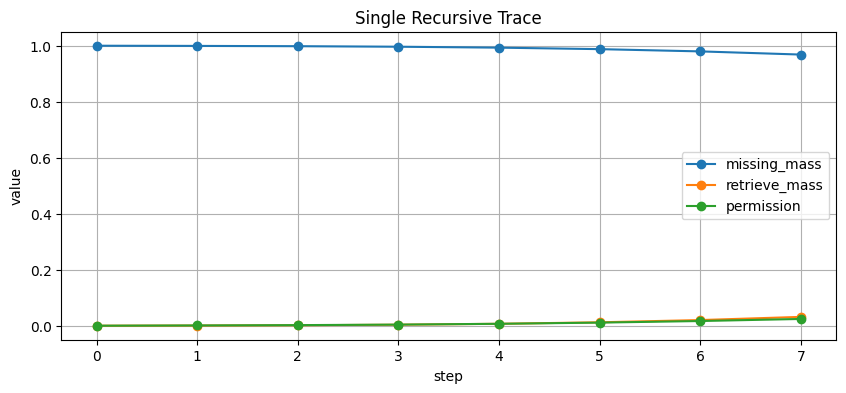

In [16]:

plt.figure(figsize=(10, 4))
plt.plot(trace_df["step"], trace_df["missing_mass"], marker="o", label="missing_mass")
plt.plot(trace_df["step"], trace_df["retrieve_mass"], marker="o", label="retrieve_mass")
plt.plot(trace_df["step"], trace_df["permission"], marker="o", label="permission")
plt.title("Single Recursive Trace")
plt.xlabel("step")
plt.ylabel("value")
plt.legend()
plt.show()


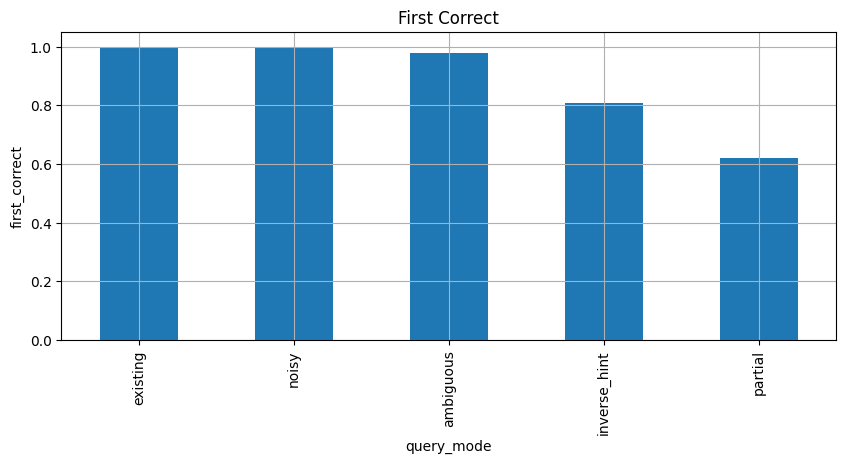

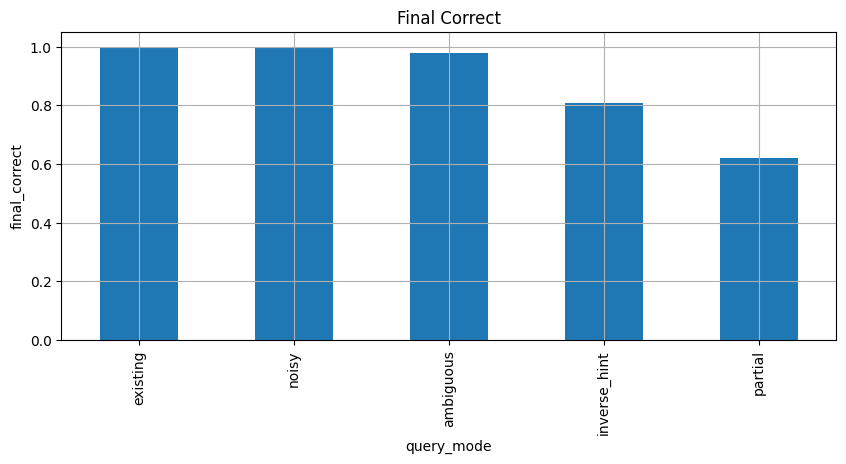

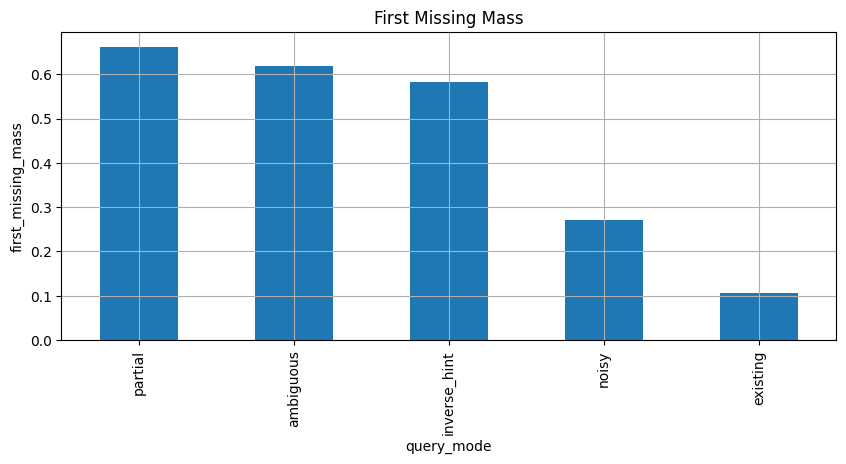

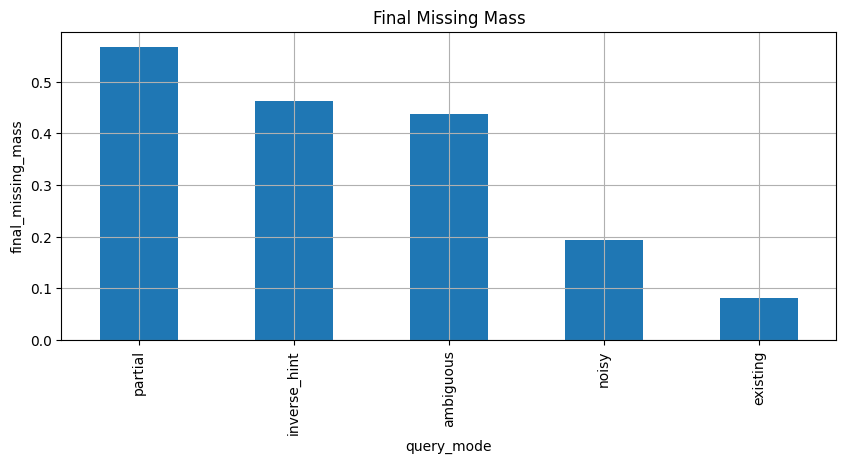

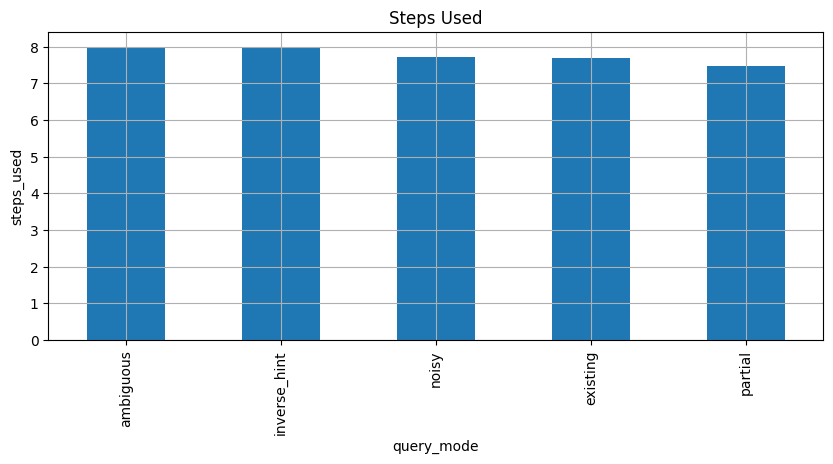

In [17]:

metrics = ["first_correct", "final_correct", "first_missing_mass", "final_missing_mass", "steps_used"]

for metric in metrics:
    plt.figure(figsize=(10, 4))
    grouped = compare_df.groupby("query_mode")[metric].mean().sort_values(ascending=False)
    grouped.plot(kind="bar")
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("query_mode")
    plt.ylabel(metric)
    plt.show()



## Practical readout

This notebook adds the missing recursion loop.

It should answer the exact question:
- is the controller merely reading the right field?
- or can it use that field recursively to improve closure?

The main tables are:

- `recursive_summary`
- `by_mode_compare`
- `partial_summary`
- `trace_df`

The main target is:
- higher final accuracy than first pass
- lower final missing mass than first pass
- especially better behavior on `partial`
